# Actuarial Claims Reserving Workflow

## Project Information

**Project:** Actuarial Claims Reserving Workflow

**Business Function:** General Insurance Reserving

**Dataset:** CAS Workers Compensation Dataset

**Objective:**
Estimate outstanding insurance claim reserves using industry-standard actuarial reserving techniques, beginning with raw claims data and progressing through data validation, development triangle construction, Chain Ladder modelling, Mack reserving and professional reporting.

**Author:** Onyema Anthony Utulu

**Date:** July 2026

In [934]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chainladder as cl

from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [935]:
claims = pd.read_csv("../data/workers_compensation.csv")

In [936]:
# Select Allstate Insurance Group

allstate = claims[claims["GRNAME"] == "Allstate Ins Co Grp"].copy()

print(allstate.shape)
allstate.head()

(100, 13)


,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007
0,86,Allstate Ins Co Grp,1998,1998,1,10079,1201,1518,7133,-860,7993,0,135699.214
1,86,Allstate Ins Co Grp,1998,1999,2,9643,2652,240,7133,-860,7993,0,135699.214
2,86,Allstate Ins Co Grp,1998,2000,3,3207,3172,13,7133,-860,7993,0,135699.214
3,86,Allstate Ins Co Grp,1998,2001,4,3202,3178,8,7133,-860,7993,0,135699.214
4,86,Allstate Ins Co Grp,1998,2002,5,3197,3180,8,7133,-860,7993,0,135699.214


In [937]:
allstate[
    [
        "IncurredLosses",
        "CumPaidLoss",
        "BulkLoss",
        "EarnedPremNet",
        "PostedReserves2007",
    ]
].describe().round(2)

,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremNet,PostedReserves2007
count,100.00,100.00,100.00,100.0,100.00
mean,587.29,312.14,82.98,13129.9,135699.21
std,2015.50,956.23,664.81,34266.5,0.00
min,-633.00,-635.00,0.00,-336.0,135699.21
25%,0.00,0.00,0.00,-178.0,135699.21
50%,1.00,1.00,0.00,258.5,135699.21
75%,3.00,3.00,0.00,7932.0,135699.21
max,12261.00,3201.00,6487.00,114983.0,135699.21


## Portfolio Familiarisation

Following completion of the data audit, the analysis narrows its focus to **Allstate Insurance Group**, which has been selected as the representative insurer for this reserving exercise.

The original CAS Workers' Compensation database contains claims development information for **132 insurance groups**. In practice, however, reserving actuaries are typically tasked with estimating liabilities for a single insurer rather than the entire industry. Restricting the analysis to one company therefore reflects a realistic actuarial reserving engagement.

The selected portfolio contains **100 observations**, representing a complete **10 × 10 claims development triangle** comprising:

- 10 Accident Years
- 10 Development Periods

Before constructing the development triangle and estimating outstanding reserves, an exploratory review of the portfolio is performed to understand the distribution of claims, identify unusual observations, and assess whether any data issues require further investigation.

This familiarisation stage provides confidence that the portfolio is suitable for actuarial reserving analysis and establishes the foundation for the Chain Ladder methodology applied in subsequent sections.

## Portfolio Interpretation

The exploratory review indicates considerable variation in both incurred and cumulative paid losses across accident years, reflecting the heterogeneous nature of workers' compensation claims and the differing stages of claim development within the portfolio.

A small number of negative incurred and cumulative paid loss values were identified. Within insurance reserving, these observations are commonly associated with claim recoveries, reserve releases, subrogation recoveries, or accounting adjustments rather than data quality errors. Consequently, these records have been retained to preserve the integrity of the historical claims experience and will be considered during subsequent reserving analysis.

The posted reserve remains constant across all observations because it represents the insurer's aggregate reserve position at the 2007 valuation date rather than accident-year-specific reserve estimates. As such, it provides useful portfolio context but is not directly incorporated into the Chain Ladder calculations.

Overall, the portfolio demonstrates the characteristics expected of a mature workers' compensation insurance dataset and provides an appropriate foundation for constructing the claims development triangle and estimating outstanding claim liabilities.

In [938]:
(claims["CumPaidLoss"] < 0).sum()

np.int64(73)

In [939]:
claims["CumPaidLoss"].lt(0).mean()*100

np.float64(0.6033057851239669)

In [940]:
(claims["IncurredLosses"] < 0).sum()

np.int64(60)

In [941]:
(claims["IncurredLosses"] < 0).mean() * 100

np.float64(0.49586776859504134)

## Investigating Negative Claim Values

### Findings

Initial data validation identified a small number of observations containing negative values in both cumulative paid losses and incurred losses.

| Variable | Negative Records | Percentage |
|----------|-----------------:|-----------:|
| Cumulative Paid Loss | 73 | 0.60% |
| Incurred Losses | 60 | 0.50% |

These observations represent less than **1%** of the complete dataset, indicating that negative values are relatively uncommon.

### Interpretation

Negative claim values are not necessarily indicators of poor data quality within insurance reserving datasets.

In practice, they commonly arise from legitimate insurance transactions, including:

- Recovery of previous claim overpayments.
- Claim reopenings followed by revised settlements.
- Salvage and subrogation recoveries.
- Reserve releases after favourable claim development.
- Accounting corrections and financial adjustments.

Consequently, the presence of negative values is consistent with the normal administration of insurance claims and should not automatically be interpreted as data errors.

### Business Impact

Removing these observations would distort the historical claims development experience and could introduce bias into the estimation of development factors and outstanding reserves.

Retaining the observations ensures that the reserving analysis reflects the insurer's actual historical claims experience, including recoveries and reserve adjustments that form part of normal claims management.

### Professional Judgement

Given that negative observations account for less than one percent of the portfolio and have plausible operational explanations, they have been retained within the analysis.

Their influence will continue to be monitored throughout the reserving workflow, particularly during development factor estimation and reserve projection, to ensure they do not materially distort the results.

### Data Validation Summary

Additional validation confirmed that the selected portfolio contains a complete claims development structure with no material missing values or duplicate records affecting the reserving analysis. The development periods are consistent with the expected triangle format required for the Chain Ladder methodology.

Overall, the portfolio was considered suitable for actuarial reserving, with the only notable feature being a small number of legitimate negative claim values, which were retained following professional review.

## Construction of the Paid Loss Development Triangle

The original claims data is stored in a longitudinal format, where each observation represents an accident year at a particular development period.

To apply the Chain Ladder methodology, the data is transformed into a cumulative paid loss development triangle. This actuarial representation enables historical claims development to be analysed systematically and provides the foundation for estimating future claim liabilities using development factors.

In [942]:
paid_triangle = allstate.pivot(
    index="AccidentYear",
    columns="DevelopmentLag",
    values="CumPaidLoss"
)

paid_triangle.to_csv(
    "../outputs/paid_loss_triangle.csv"
)

paid_triangle

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,1201,2652,3172,3178,3180,3181,3181,3181,3201,3200
1999,741,820,823,825,825,825,825,825,825,825
2000,-635,-634,-633,-633,-633,-633,-633,-633,-633,-633
2001,0,1,1,1,4,1,2,2,1,1
2002,1,1,1,1,1,1,1,1,1,1
2003,0,0,1,3,3,3,3,3,3,3
2004,0,0,0,0,0,0,0,0,0,0
2005,0,3,3,3,3,3,0,0,0,0
2006,0,0,0,0,0,0,0,0,0,0


### Interpretation

The paid loss development triangle summarises the cumulative progression of claim payments for each accident year across successive development periods, providing the structured format required for actuarial reserve estimation.

Each row represents a single accident year, while each column captures cumulative paid losses at a specific development age. This structure enables the evolution of claims to be observed over time and facilitates the estimation of future claim development.

The triangle highlights differences in claim maturity across accident years, reflecting the natural variation in claims settlement patterns within the insurance portfolio. These differences underpin the estimation of age-to-age development factors used in the Chain Ladder methodology.

The negative cumulative values observed for Accident Year 2000 are consistent with the findings from the data validation stage and have been retained as legitimate historical claim adjustments rather than data quality issues.

Overall, the development triangle provides the actuarial foundation for projecting ultimate losses and estimating outstanding claim reserves in the subsequent stages of the analysis.

## Age-to-Age Development Factors

The next stage of the reserving process is to estimate how claims develop between successive development periods.

This is achieved by calculating **Age-to-Age Development Factors (Link Ratios)**, which measure the historical growth in cumulative paid losses from one development period to the next.

These factors capture the portfolio's observed claims development pattern and form the basis of the deterministic Chain Ladder methodology.

Once estimated, they will be applied to immature accident years to project ultimate claim costs and calculate outstanding claim reserves.

In [943]:
development_factors_clean = development_factors.replace(
    [np.inf, -np.inf],
    np.nan
)

development_factors_clean

DevelopmentLag,1,2,3,4,5,6,7,8,9
AccidentYear,,,,,,,,,
1998,2.208160,1.196078,1.001892,1.000629,1.000314,1.0,1.0,1.006287,0.999688
1999,1.106613,1.003659,1.002430,1.000000,1.000000,1.0,1.0,1.000000,NaN
2000,0.998425,0.998423,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
2001,NaN,1.000000,1.000000,4.000000,0.250000,2.0,NaN,NaN,NaN
2002,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
2003,NaN,NaN,3.000000,1.000000,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cleaning and Selecting Development Factors

The raw age-to-age development factors contain undefined (`NaN`) and infinite (`Inf`) values arising from zero cumulative paid losses and incomplete development histories.

Before applying the Chain Ladder methodology, these anomalous values are excluded to ensure that the selected development factors are based on meaningful historical claims experience.

The cleaned development factors are then summarised to identify representative development patterns for projecting immature accident years.

## Creating the Reserving Valuation Triangle

The original dataset contains claim development observations extending to the final available development period for each accident year. Using the complete dataset directly would provide information that would not have been available to an actuary at an earlier valuation date.

To create a realistic reserving exercise, future development observations are removed along a common valuation diagonal. Older accident years therefore retain more development history, while more recent accident years contain fewer observed development periods.

The resulting upper triangle represents the cumulative paid claims information assumed to be available at the selected valuation date. This triangle forms the basis for estimating development factors, ultimate losses and outstanding claim reserves.

In [944]:
first_accident_year = allstate["AccidentYear"].min()
maximum_development_lag = allstate["DevelopmentLag"].max()

valuation_data = allstate[
    allstate["DevelopmentLag"]
    <= (
        maximum_development_lag
        - (allstate["AccidentYear"] - first_accident_year)
    )
].copy()

In [945]:
valuation_triangle = valuation_data.pivot_table(
    index="AccidentYear",
    columns="DevelopmentLag",
    values="CumPaidLoss",
    aggfunc="sum"
)

valuation_triangle

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1998,1201.0,2652.0,3172.0,3178.0,3180.0,3181.0,3181.0,3181.0,3201.0,3200.0
1999,741.0,820.0,823.0,825.0,825.0,825.0,825.0,825.0,825.0,NaN
2000,-635.0,-634.0,-633.0,-633.0,-633.0,-633.0,-633.0,-633.0,NaN,NaN
2001,0.0,1.0,1.0,1.0,4.0,1.0,2.0,NaN,NaN,NaN
2002,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2003,0.0,0.0,1.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN
2004,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2005,0.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [946]:
expected_latest_lag = (
    maximum_development_lag
    - (
        valuation_triangle.index
        - first_accident_year
    )
)

actual_latest_lag = valuation_triangle.apply(
    lambda row: row.last_valid_index(),
    axis=1
)

valuation_check = pd.DataFrame({
    "Expected Latest Lag": expected_latest_lag,
    "Actual Latest Lag": actual_latest_lag
})

valuation_check["Valid"] = (
    valuation_check["Expected Latest Lag"]
    == valuation_check["Actual Latest Lag"]
)

valuation_check

,Expected Latest Lag,Actual Latest Lag,Valid
AccidentYear,,,
1998,10,10,True
1999,9,9,True
2000,8,8,True
2001,7,7,True
2002,6,6,True
2003,5,5,True
2004,4,4,True
2005,3,3,True
2006,2,2,True


In [947]:
assert valuation_check["Valid"].all(), (
    "The valuation triangle does not follow the expected diagonal."
)

In [948]:
## Calculating Age-to-Age Development Factors
development_factors = valuation_triangle.shift(-1, axis=1) / valuation_triangle
development_factors = development_factors.iloc[:, :-1]

development_factors

DevelopmentLag,1,2,3,4,5,6,7,8,9
AccidentYear,,,,,,,,,
1998,2.208160,1.196078,1.001892,1.000629,1.000314,1.0,1.0,1.006287,0.999688
1999,1.106613,1.003659,1.002430,1.000000,1.000000,1.0,1.0,1.000000,NaN
2000,0.998425,0.998423,1.000000,1.000000,1.000000,1.0,1.0,NaN,NaN
2001,inf,1.000000,1.000000,4.000000,0.250000,2.0,NaN,NaN,NaN
2002,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
2003,NaN,inf,3.000000,1.000000,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,inf,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [949]:
## Development Factor Selection

development_factors_clean = development_factors.replace(
    [np.inf, -np.inf],
    np.nan
)

In [950]:
observed_factors = {}
factor_observations = {}

for current_lag, next_lag in zip(
    valuation_triangle.columns[:-1],
    valuation_triangle.columns[1:]
):
    valid = (
        valuation_triangle[current_lag].notna()
        & valuation_triangle[next_lag].notna()
        & valuation_triangle[current_lag].ne(0)
    )

    factor_observations[current_lag] = valid.sum()

    denominator = valuation_triangle.loc[
        valid, current_lag
    ].sum()

    numerator = valuation_triangle.loc[
        valid, next_lag
    ].sum()

    observed_factors[current_lag] = (
        numerator / denominator
        if denominator != 0
        else np.nan
    )

observed_factors = pd.Series(
    observed_factors,
    name="Observed LDF"
)

factor_observations = pd.Series(
    factor_observations,
    name="Observations"
)

In [951]:
selected_factors = observed_factors.copy()

late_periods = selected_factors.index >= 5

selected_factors.loc[late_periods] = (
    selected_factors.loc[late_periods]
    .clip(lower=1.0)
)

selected_factors.name = "Selected LDF"

In [952]:
factor_selection = pd.DataFrame({
    "Observations": factor_observations,
    "Observed LDF": observed_factors,
    "Selected LDF": selected_factors
})

factor_selection["Adjustment"] = np.where(
    factor_selection["Observed LDF"].round(6)
    != factor_selection["Selected LDF"].round(6),
    "Adjusted to minimum 1.00",
    "No adjustment"
)

factor_selection

,Observations,Observed LDF,Selected LDF,Adjustment
1,4,2.170489,2.170489,No adjustment
2,6,1.184312,1.184312,No adjustment
3,6,1.002972,1.002972,No adjustment
4,6,1.001481,1.001481,No adjustment
5,5,0.999408,1.000000,Adjusted to minimum 1.00
6,4,1.000296,1.000296,No adjustment
7,3,1.000000,1.000000,No adjustment
8,2,1.004993,1.004993,No adjustment
9,1,0.999688,1.000000,Adjusted to minimum 1.00


### Development Factor Selection Judgement

Observed volume-weighted link ratios were reviewed before being selected for projection. Factors below 1.00 may arise from recoveries, payment reversals, accounting corrections or sparse claims experience and were therefore not automatically treated as data errors.

For this demonstration, factors from Development Lag 5 onward were constrained to a minimum of 1.00. This avoids projecting further reductions in cumulative paid losses during the later development periods while preserving the observed early-development pattern.

This adjustment represents an explicit actuarial selection decision rather than a mechanical data-cleaning rule. In practice, the selection would be supported by additional portfolio history, claims-operational information, diagnostic analysis and sensitivity testing.

## Cumulative Development Factors

The selected age-to-age factors are compounded to calculate cumulative development factors (CDFs). Each CDF represents the total expected development from a given development age to ultimate.

These factors are subsequently assigned to accident years according to their latest observed maturity and used to project ultimate claim costs.

In [953]:
cdf = selected_factors[::-1].cumprod()[::-1]

cdf

1    2.595656
2    1.195885
3    1.009772
4    1.006780
5    1.005290
6    1.005290
7    1.004993
8    1.004993
9    1.000000
Name: Selected LDF, dtype: float64

No explicit tail factor beyond the final observed development period has been applied; consequently, the analysis assumes that claims are fully developed by Development Lag 10.

In [954]:
selected_factors_df = pd.DataFrame({
    "Observed LDF": observed_factors,
    "Selected LDF": selected_factors,
    "CDF": cdf
})

selected_factors_df.index.name = "Development Lag"

selected_factors_df.to_csv(
    "../outputs/selected_development_factors.csv"
)

selected_factors_df.round(4)

,Observed LDF,Selected LDF,CDF
Development Lag,,,
1,2.1705,2.1705,2.5957
2,1.1843,1.1843,1.1959
3,1.0030,1.0030,1.0098
4,1.0015,1.0015,1.0068
5,0.9994,1.0000,1.0053
6,1.0003,1.0003,1.0053
7,1.0000,1.0000,1.0050
8,1.0050,1.0050,1.0050
9,0.9997,1.0000,1.0000


## Estimate Ultimate Losses

The Chain Ladder method projects each accident year's latest cumulative paid losses to their estimated ultimate value using the selected cumulative development factors (CDFs).

The latest observed paid loss is first identified for each accident year before the appropriate development factor is applied.

In [955]:
latest_paid = valuation_triangle.apply(
    lambda row: row.dropna().iloc[-1],
    axis=1
)

latest_paid.name = "Latest Paid"


In [956]:
latest_age = valuation_triangle.apply(
    lambda row: row.last_valid_index(),
    axis=1
)

latest_age.name = "Latest Development Lag"


In [957]:
assigned_cdf = latest_age.map(cdf)

assigned_cdf = assigned_cdf.fillna(1.0)


In [958]:
ultimate_loss = latest_paid * assigned_cdf

ultimate_loss.name = "Ultimate Loss"


In [959]:
projection_inputs = pd.DataFrame({
    "Latest Paid": latest_paid,
    "Development Age": latest_age,
    "Assigned CDF": assigned_cdf,
    "Ultimate Loss": ultimate_loss
})
projection_inputs.round(4)

projection_inputs.to_csv(
    "../outputs/projection_inputs.csv")

projection_inputs

,Latest Paid,Development Age,Assigned CDF,Ultimate Loss
AccidentYear,,,,
1998,3200.0,10,1.000000,3200.000000
1999,825.0,9,1.000000,825.000000
2000,-633.0,8,1.004993,-636.160260
2001,2.0,7,1.004993,2.009985
2002,1.0,6,1.005290,1.005290
2003,3.0,5,1.005290,3.015871
2004,0.0,4,1.006780,0.000000
2005,3.0,3,1.009772,3.029315
2006,0.0,2,1.195885,0.000000


### Business Interpretation

The latest observed development lag measures the maturity of each accident year at the valuation date.

Older accident years contain more development experience and generally require less additional projection. More recent accident years remain less mature and therefore rely more heavily on the selected development pattern.

The latest observed lag determines the cumulative development factor applied to each accident year when estimating ultimate claim costs.

## Calculate Outstanding Reserves

Outstanding reserves represent the future claim payments expected after the valuation date.

Under the Chain Ladder method, the outstanding reserve is calculated as the difference between the estimated ultimate loss and the cumulative paid losses observed at the valuation date.

These reserves represent the insurer's remaining liability for each accident year.

In [960]:
outstanding_reserve = ultimate_loss - latest_paid

outstanding_reserve.name = "Outstanding Reserve"

outstanding_reserve

AccidentYear
1998    0.000000
1999    0.000000
2000   -3.160260
2001    0.009985
2002    0.005290
2003    0.015871
2004    0.000000
2005    0.029315
2006    0.000000
2007    0.000000
Name: Outstanding Reserve, dtype: float64

In [961]:
reserve_summary = pd.DataFrame({

    "Latest Paid Loss": latest_paid,

    "Assigned CDF": assigned_cdf,

    "Estimated Ultimate Loss": ultimate_loss,

    "Outstanding Reserve": outstanding_reserve,
    
    "Development Age": latest_age

})

reserve_summary["Reserve % of Ultimate"] = (
    reserve_summary["Outstanding Reserve"]
    / reserve_summary["Estimated Ultimate Loss"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0).round(3)

reserve_summary

,Latest Paid Loss,Assigned CDF,Estimated Ultimate Loss,Outstanding Reserve,Development Age,Reserve % of Ultimate
AccidentYear,,,,,,
1998,3200.0,1.000000,3200.000000,0.000000,10,0.000
1999,825.0,1.000000,825.000000,0.000000,9,0.000
2000,-633.0,1.004993,-636.160260,-3.160260,8,0.005
2001,2.0,1.004993,2.009985,0.009985,7,0.005
2002,1.0,1.005290,1.005290,0.005290,6,0.005
2003,3.0,1.005290,3.015871,0.015871,5,0.005
2004,0.0,1.006780,0.000000,0.000000,4,0.000
2005,3.0,1.009772,3.029315,0.029315,3,0.010
2006,0.0,1.195885,0.000000,0.000000,2,0.000


In [962]:
totals = pd.DataFrame({
    "Latest Paid Loss": [reserve_summary["Latest Paid Loss"].sum()],
    "Estimated Ultimate Loss": [reserve_summary["Estimated Ultimate Loss"].sum()],
    "Outstanding Reserve": [reserve_summary["Outstanding Reserve"].sum()]
}, index=["Total"])

totals

,Latest Paid Loss,Estimated Ultimate Loss,Outstanding Reserve
Total,3401.0,3397.900202,-3.099798


### Business Interpretation

The reserve summary combines each accident year's latest observed cumulative paid losses with the selected cumulative development factors to estimate ultimate claim costs and outstanding reserves.

Older accident years are largely developed and therefore require little or no additional reserve, while more recent accident years remain immature and rely on larger development factors to project future claim payments.

One accident year produces a small negative reserve estimate. This does not necessarily indicate a modelling error but highlights the importance of actuarial judgement when interpreting reserve estimates. In practice, such cases would be investigated further by reviewing claim files, recoveries, operational changes and alternative reserving methods before any management adjustments are made.

Overall, the results demonstrate how the Chain Ladder methodology transforms historical claims development into reserve estimates that support insurer financial reporting, capital management and solvency assessment.

# Mack Chain Ladder

The Mack Chain Ladder model extends the deterministic Chain Ladder method by providing an estimate of reserve uncertainty.

Unlike the deterministic approach, which produces only a single estimate of ultimate losses, the Mack model also calculates the standard error associated with each reserve estimate. This allows the actuary to assess the reliability of the projected reserves.


In [963]:
triangle = cl.Triangle(
    valuation_data,
    origin="AccidentYear",
    development="DevelopmentYear",
    columns="CumPaidLoss",
    cumulative=True
)

triangle

,12,24,36,48,60,72,84,96,108,120
1998,"1,201.00","2,652.00","3,172.00","3,178.00","3,180.00","3,181.00","3,181.00","3,181.00","3,201.00","3,200.00"
1999,741.00,820.00,823.00,825.00,825.00,825.00,825.00,825.00,825.00,
2000,-635.00,-634.00,-633.00,-633.00,-633.00,-633.00,-633.00,-633.00,,
2001,,1.00,1.00,1.00,4.00,1.00,2.00,,,
2002,1.00,1.00,1.00,1.00,1.00,1.00,,,,
2003,,,1.00,3.00,3.00,,,,,
2004,,,,,,,,,,
2005,,3.00,3.00,,,,,,,
2006,,,,,,,,,,
2007,,,,,,,,,,


In [964]:
mack = cl.MackChainladder().fit(triangle)

c:\Users\utulu\AppData\Local\Programs\Python\Python313\Lib\site-packages\chainladder\utils\weighted_regression.py:84: RuntimeWarning: invalid value encountered in sqrt
  residual = (y - fitted_value) * xp.sqrt(w)
c:\Users\utulu\AppData\Local\Programs\Python\Python313\Lib\site-packages\chainladder\development\development.py:203: RuntimeWarning: invalid value encountered in sqrt
  / xp.swapaxes(xp.sqrt(x ** (2 - exponent))[..., 0:1, :], -1, -2)
c:\Users\utulu\AppData\Local\Programs\Python\Python313\Lib\site-packages\chainladder\development\development.py:214: RuntimeWarning: invalid value encountered in sqrt
  std = xp.sqrt((1 / num_to_nan(w)) * (self.sigma_**2).values)
c:\Users\utulu\AppData\Local\Programs\Python\Python313\Lib\site-packages\chainladder\methods\mack.py:243: RuntimeWarning: invalid value encountered in sqrt
  weight = xp.sqrt(full.values[..., : len(X.ddims)] ** (2 - val))


In [965]:
mack_summary = mack.summary_.to_frame()

mack_summary

,Latest,IBNR,Ultimate,Mack Std Err
1998-01-01,3200.0,NaN,3200.000000,NaN
1999-01-01,825.0,-0.257732,824.742268,9.093639e-126
2000-01-01,-633.0,-2.961522,-635.961522,1.608912e+00
2001-01-01,2.0,0.009357,2.009357,2.275660e-01
2002-01-01,1.0,0.004976,1.004976,6.019740e-01
2003-01-01,3.0,0.013143,3.013143,1.671069e+00
2004-01-01,NaN,NaN,NaN,NaN
2005-01-01,3.0,0.026575,3.026575,3.270493e+00
2006-01-01,NaN,NaN,NaN,NaN
2007-01-01,NaN,NaN,NaN,NaN


In [966]:
mack_summary.to_csv(
    "../outputs/mack_chainladder_summary.csv"
)

## Mack Chain Ladder Results

The Mack Chain Ladder model produces reserve estimates broadly consistent with the deterministic Chain Ladder results for the accident years where sufficient claims development information is available.

Accident Years 2001, 2002, 2003 and 2005 show progressively greater reserve uncertainty, with Mack Standard Errors increasing from approximately 0.23 to 3.27. This reflects the greater reliance on projected future development for less mature accident years.

Accident Year 2000 produces a negative IBNR estimate, consistent with the negative cumulative paid losses and historical recoveries identified during the data validation stage. The associated standard error indicates that uncertainty remains around this negative reserve estimate.

Several accident years contain missing Mack estimates. These missing values arise from the sparse claims experience, zero cumulative paid losses and insufficient development information within the demonstration dataset. Consequently, the Mack results should be interpreted as an illustration of reserve uncertainty rather than a complete portfolio-level uncertainty assessment.

Overall, the Mack Chain Ladder analysis adds value by supplementing the deterministic reserve estimates with measures of uncertainty. This additional information can support reserve governance, capital assessment and management judgement when evaluating the reliability of projected claim liabilities.

In [967]:
plot_data = reserve_summary[
    [
        "Latest Paid Loss",
        "Estimated Ultimate Loss",
        "Outstanding Reserve"
    ]
].copy()

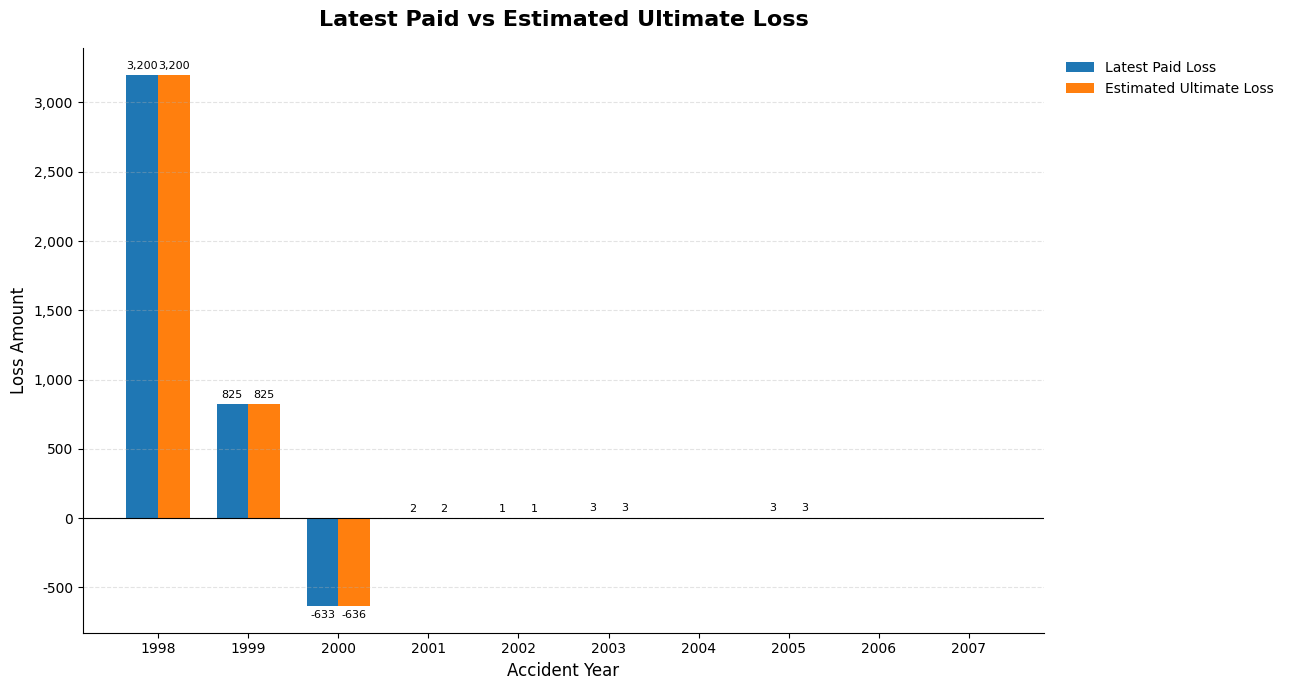

In [968]:
fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(plot_data))
width = 0.35

# Latest Paid bars
latest_paid_bars = ax.bar(
    [i - width / 2 for i in x],
    plot_data["Latest Paid Loss"],
    width=width,
    label="Latest Paid Loss"
)

# Ultimate Loss bars
ultimate_loss_bars = ax.bar(
    [i + width / 2 for i in x],
    plot_data["Estimated Ultimate Loss"],
    width=width,
    label="Estimated Ultimate Loss"
)

ax.set_title(
    "Latest Paid vs Estimated Ultimate Loss",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Accident Year", fontsize=12)
ax.set_ylabel("Loss Amount", fontsize=12)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data.index.astype(str))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.grid(axis="x", visible=False)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add value labels once
for container in [latest_paid_bars, ultimate_loss_bars]:
    labels = [
        f"{value:,.0f}" if value != 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=8,
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/latest_paid_vs_ultimate_loss.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

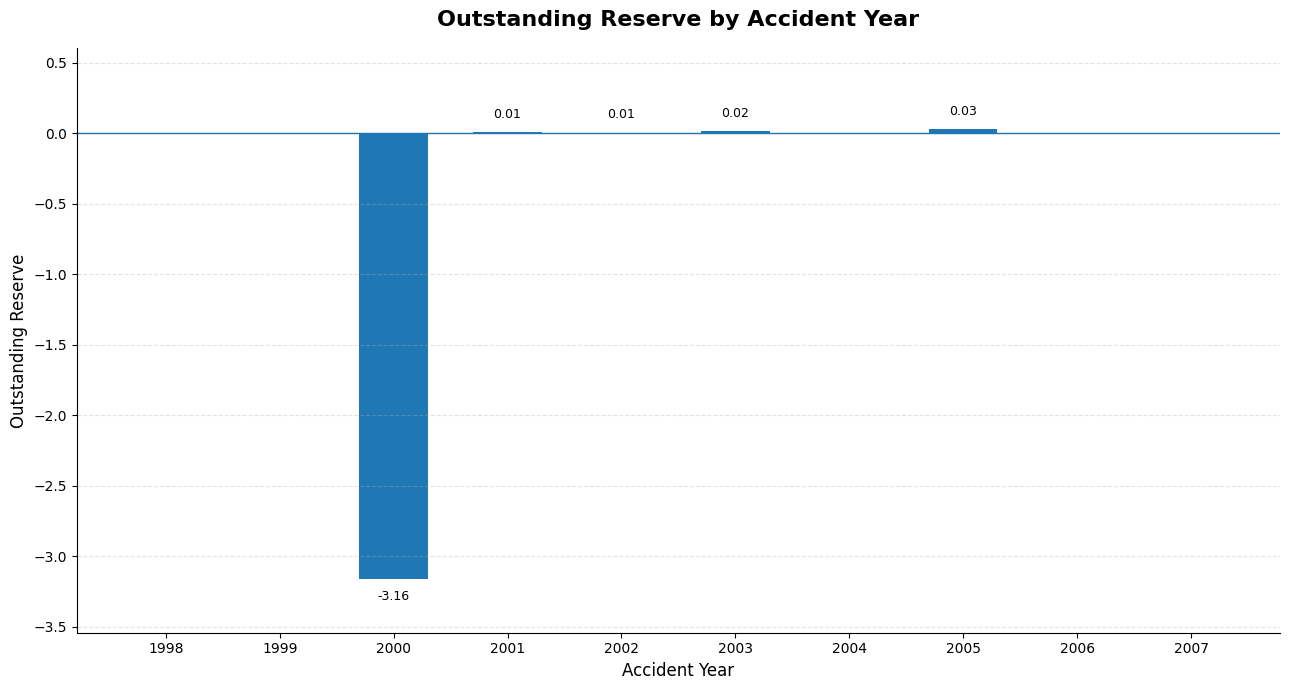

In [969]:
fig, ax = plt.subplots(figsize=(13, 7))

reserve_bars = ax.bar(
    reserve_summary.index.astype(str),
    reserve_summary["Outstanding Reserve"],
    width=0.6
)

ax.set_title(
    "Outstanding Reserve by Accident Year",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Accident Year",
    fontsize=12
)

ax.set_ylabel(
    "Outstanding Reserve",
    fontsize=12
)

ax.axhline(
    0,
    linewidth=1
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add labels with spacing based on the chart scale
y_range = (
    reserve_summary["Outstanding Reserve"].max()
    - reserve_summary["Outstanding Reserve"].min()
)

label_offset = y_range * 0.025

for bar in reserve_bars:
    value = bar.get_height()

    if abs(value) < 0.0005:
        continue

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + label_offset if value > 0 else value - label_offset,
        f"{value:,.2f}",
        ha="center",
        va="bottom" if value > 0 else "top",
        fontsize=9
    )

# Add extra vertical space for labels
minimum = reserve_summary["Outstanding Reserve"].min()
maximum = reserve_summary["Outstanding Reserve"].max()

ax.set_ylim(
    minimum - (y_range * 0.12),
    maximum + (y_range * 0.18)
)

plt.tight_layout()

plt.savefig(
    "../visualizations/outstanding_reserve_by_year.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Interpretation

The outstanding reserve analysis indicates that the earliest accident years are substantially developed and therefore require little or no additional reserve, as most claim payments have already been recognised.

Less mature accident years retain positive outstanding reserves because additional claim development is expected beyond the valuation date. These reserves represent the insurer's estimated future payment obligations and form an important component of financial reporting and capital management.

The negative reserve observed for Accident Year 2000 reflects the negative cumulative paid losses identified during earlier data validation. This is most likely attributable to claim recoveries or accounting adjustments rather than an indication of negative insurance liabilities, and has been retained to preserve the integrity of the historical claims data.

Together, the reserve estimates and the comparison between latest paid and ultimate losses provide insight into the timing and magnitude of future claim payments, supporting actuarial reserving decisions and the assessment of the insurer's remaining claims obligations.

## Comparison of Chain Ladder and Mack Chain Ladder

In [970]:
# Prepare Chain Ladder reserve series
chain_reserve = outstanding_reserve.copy()
chain_reserve.index = pd.Index(
    [pd.to_datetime(value).year if not str(value).isdigit() else int(value)
     for value in chain_reserve.index],
    name="Accident Year"
)

# Prepare Mack reserve series
mack_reserve = mack_summary["IBNR"].copy()

mack_reserve.index = pd.Index(
    [pd.to_datetime(value).year if not str(value).isdigit() else int(value)
     for value in mack_reserve.index],
    name="Accident Year"
)

# Convert values to numeric
chain_reserve = pd.to_numeric(chain_reserve, errors="coerce")
mack_reserve = pd.to_numeric(mack_reserve, errors="coerce")

# Build the correctly aligned comparison table
comparison = pd.concat(
    [
        chain_reserve.rename("Chain Ladder Reserve"),
        mack_reserve.rename("Mack Reserve")
    ],
    axis=1
).sort_index()

comparison

,Chain Ladder Reserve,Mack Reserve
Accident Year,,
1998,0.000000,NaN
1999,0.000000,-0.257732
2000,-3.160260,-2.961522
2001,0.009985,0.009357
2002,0.005290,0.004976
2003,0.015871,0.013143
2004,0.000000,NaN
2005,0.029315,0.026575
2006,0.000000,NaN


### Business Interpretation

The comparison demonstrates that the deterministic Chain Ladder and stochastic Mack Chain Ladder methods produce broadly consistent reserve estimates across the accident years analysed. This close agreement suggests that the projected outstanding liabilities are relatively stable regardless of the reserving approach applied.

Small differences between the two methods arise because the Mack Chain Ladder incorporates process variability and estimates the uncertainty surrounding future claim development, whereas the deterministic Chain Ladder provides a single point estimate without explicitly measuring reserve uncertainty.

The most noticeable variation occurs for Accident Year 1999, where the Mack method estimates a small negative reserve while the deterministic method indicates a fully developed position. Given the magnitude of this difference, it is unlikely to have a material impact on the insurer's overall reserve position and is consistent with normal modelling variation.

Overall, the close alignment between the two methods increases confidence in the reserve estimates while demonstrating the additional analytical value of stochastic reserving techniques for assessing reserve uncertainty and supporting risk-based decision-making.

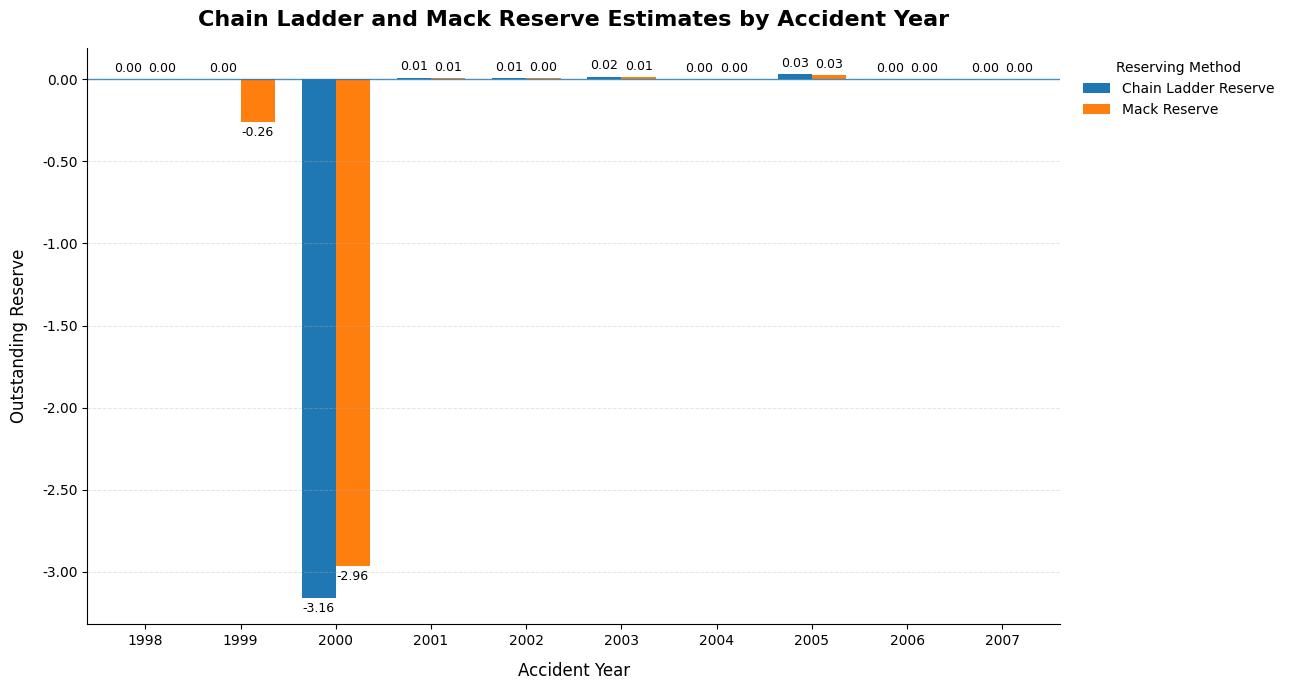

In [971]:
plot_data = comparison.copy()

fig, ax = plt.subplots(figsize=(13, 7))

plot_data.plot(
    kind="bar",
    ax=ax,
    width=0.72
)

ax.set_title(
    "Chain Ladder and Mack Reserve Estimates by Accident Year",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Accident Year",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Outstanding Reserve",
    fontsize=12,
    labelpad=10
)

ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.2f}")
)

ax.axhline(
    y=0,
    linewidth=1,
    alpha=0.8
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(axis="x", visible=False)

ax.legend(
    title="Reserving Method",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

# Add value labels to improve readability
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/chainladder_vs_mack.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Final Results Summary

This project successfully implemented a complete actuarial claims reserving workflow using the deterministic Chain Ladder and stochastic Mack Chain Ladder methodologies.

Historical claims data were transformed into cumulative development triangles, development factors were estimated, and outstanding claim liabilities were projected using established actuarial reserving techniques. The analysis also incorporated reserve uncertainty through the Mack Chain Ladder model, providing additional insight into the reliability of the reserve estimates.

The results demonstrate how Python can be used to produce transparent, reproducible, and business-focused actuarial analyses that support reserve estimation, financial reporting, and risk management within general insurance.

# Model Assumptions

The Chain Ladder methodology relies on several important assumptions:

- Historical claims development patterns are expected to remain broadly representative of future claims development.
- Claims are reported and settled consistently over time.
- There are no material changes in claims handling practices, underwriting strategy, legislation, inflation, or the external operating environment.
- Development factors remain stable across accident years.
- Past claims development provides a reliable basis for projecting future development.

# Model Limitations

Although the Chain Ladder method is widely used in actuarial reserving, several limitations should be recognised:

- The method is sensitive to unusual claims experience and large outliers.
- Significant changes in claims development patterns may reduce forecasting accuracy.
- The model assumes relatively homogeneous development across accident years.
- Economic inflation and operational changes are not explicitly modelled.
- Reliable estimates depend on sufficient historical claims development data.
- The model does not explicitly incorporate expert actuarial judgement, which may be required when significant operational or market changes occur.

The Mack Chain Ladder extends the deterministic approach by quantifying reserve uncertainty; however, it still relies on the same underlying development assumptions.

# Conclusion

This project demonstrates an end-to-end actuarial claims reserving workflow using Python, combining traditional reserving techniques with modern data analytics practices.

Both the deterministic Chain Ladder and stochastic Mack Chain Ladder methods produced broadly consistent reserve estimates, providing confidence in the projected outstanding liabilities while also illustrating the value of incorporating reserve uncertainty into actuarial decision-making.

Beyond implementing the underlying calculations, the project emphasised data quality assessment, transparent modelling assumptions, business interpretation, and clear visual communication of results. These are essential components of actuarial reserving within the general insurance industry.

Overall, the project demonstrates the practical application of actuarial science, statistical modelling, and Python programming to support evidence-based reserving, financial reporting, and risk management.

# Skills Demonstrated

- Actuarial Claims Reserving
- Deterministic Chain Ladder Method
- Mack Chain Ladder Method
- Loss Development Triangles
- Development Factor Selection
- Deterministic and Stochastic Reserve Estimation
- Python (Pandas, NumPy, Matplotlib)
- Chainladder Python Library
- Data Cleaning and Validation
- Statistical Modelling and Reserve Uncertainty Analysis
- Actuarial Reporting
- Business Interpretation of Actuarial Results
- Data Visualisation
- Financial Risk Analysis